# Claims Analysis
Quick look at the claims data. Run cells top to bottom.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 1

(20000, 7)
policy_id           str
claim_date          str
peril               str
region              str
claim_amount    float64
premium         float64
loss_year         int64
dtype: object


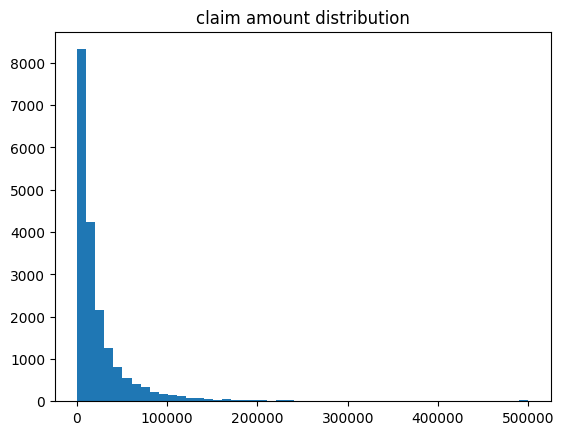

In [2]:
# Load data and do a quick first look
DF = pd.read_csv("data/claims_sample.csv")

DF.head()
print(DF.shape)
print(DF.dtypes)
plt.hist(DF['claim_amount'].dropna(), bins=50)
plt.title('claim amount distribution')
plt.show()

## Data prep

In [3]:
# must run after cell above

# clean up the BE region subset
BE_regions = ["BE-BRU", "BE-VLG"]
ClaimData = DF[DF['region'].isin(BE_regions)].copy()
ClaimData = ClaimData[ClaimData['claim_amount'].notna()]
ClaimData = ClaimData[~ClaimData['peril'].isin(['UNKNOWN', ''])]
ClaimData['claim_date'] = pd.to_datetime(ClaimData['claim_date'], format='mixed', dayfirst=True)
ClaimData['claim_amount'] = ClaimData['claim_amount'].astype(float)
ClaimData['premium'] = ClaimData['premium'].astype(float)
ClaimData = ClaimData.drop_duplicates(subset=['policy_id', 'claim_date'])
ClaimData = ClaimData.reset_index(drop=True)

print('BE subset shape:', ClaimData.shape)
ClaimData.head()

BE subset shape: (5390, 7)


,policy_id,claim_date,peril,region,claim_amount,premium,loss_year
0,POL-875935,2024-04-17,theft,BE-VLG,12504.17,3226.75,2024
1,POL-203229,2024-11-17,theft,BE-VLG,30151.68,3079.51,2024
2,POL-757503,2022-03-07,storm,BE-VLG,2155.42,3878.83,2022
3,POL-098830,2021-08-11,flood,BE-BRU,908.05,307.92,2021
4,POL-890407,2020-11-29,flood,BE-VLG,7271.39,3090.52,2020


In [ ]:
# same cleaning for NL
NL_regions = ["NL-NH", "NL-ZH"]
Data = DF[DF['region'].isin(NL_regions)].copy()
Data = Data[Data['claim_amount'].notna()]
Data = Data[~Data['peril'].isin(['UNKNOWN', ''])]
Data['claim_date'] = pd.to_datetime(Data['claim_date'], format='mixed', dayfirst=True)
Data['claim_amount'] = Data['claim_amount'].astype(float)
Data['premium'] = Data['premium'].astype(float)
Data = Data.drop_duplicates(subset=['policy_id'])
Data = Data.reset_index(drop=True)

print('NL subset shape:', Data.shape)
Data.head()

In [4]:
# same for DE
DE_Regions = ["DE-BAY", "DE-NRW"]
d = DF[DF['region'].isin(DE_Regions)].copy()
d = d[d['claim_amount'].notna()]
d = d[~d['peril'].isin(['UNKNOWN', ''])]
d['claim_date'] = pd.to_datetime(d['claim_date'], format='mixed', dayfirst=True)
d['claim_amount'] = d['claim_amount'].astype(float)
d['premium'] = d['premium'].astype(float)
d = d.drop_duplicates(subset=['policy_id', 'claim_date'])
d = d.reset_index(drop=True)

print('DE subset shape:', d.shape)
d.head()

DE subset shape: (4695, 7)


,policy_id,claim_date,peril,region,claim_amount,premium,loss_year
0,POL-602276,2020-12-06,theft,DE-BAY,280032.31,5000.00,2020
1,POL-016525,2023-10-04,water_damage,DE-NRW,9624.17,2301.80,2023
2,POL-661713,2020-06-21,storm,DE-BAY,31690.38,691.61,2020
3,POL-836394,2023-06-09,storm,DE-BAY,8598.58,2225.43,2023
4,POL-329500,2023-03-08,liability,DE-BAY,21411.31,4989.35,2023


## Analysis

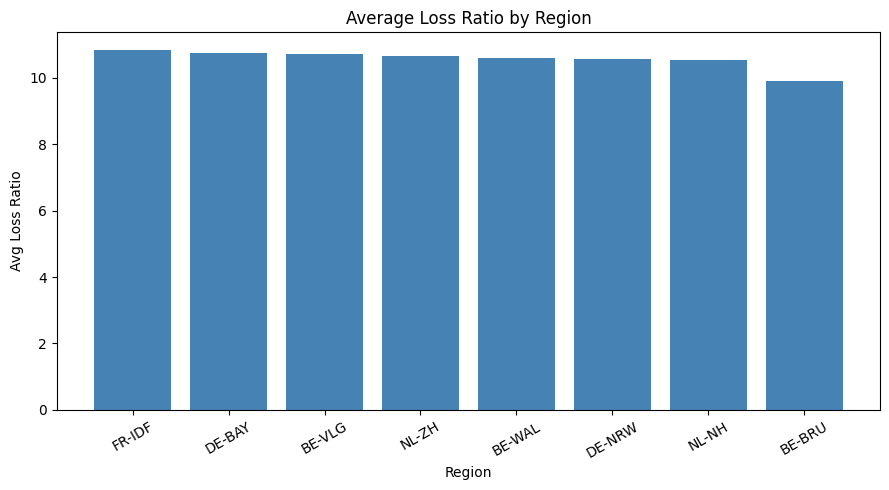

High-risk policies: 8706
     policy_id  claim_amount  region         peril
0   POL-602276     280032.31  DE-BAY         theft
1   POL-804025      22195.18   NL-NH         theft
4   POL-930086      18437.10  BE-WAL          fire
9   POL-661713      31690.38  DE-BAY         storm
10  POL-965687      47680.74   NL-ZH         storm
11  POL-203229      30151.68  BE-VLG         theft
13  POL-225258      20183.94   NL-NH          fire
14  POL-329500      21411.31  DE-BAY     liability
16  POL-959807      52112.48   NL-NH         flood
17  POL-652614      35825.14   NL-NH          fire
18  POL-498251      43618.99  BE-WAL     liability
19  POL-982661      19428.22   NL-ZH     liability
29  POL-821442      45413.25  BE-VLG         storm
33  POL-274499      23060.89  DE-NRW  water_damage
35  POL-570558      56136.94  BE-WAL         theft
36  POL-190156      21691.66  DE-NRW         theft
37  POL-218256      70025.51   NL-ZH         storm
38  POL-455927      23122.97  FR-IDF         storm
42  PO

In [ ]:
DF2 = pd.read_csv("data/claims_sample.csv")
DF2 = DF2[DF2['claim_amount'].notna()]
DF2 = DF2[~DF2['peril'].isin(['UNKNOWN', ''])]
DF2['claim_date'] = pd.to_datetime(DF2['claim_date'], format='mixed', dayfirst=True)
DF2['claim_amount'] = DF2['claim_amount'].astype(float)
DF2['premium'] = DF2['premium'].astype(float)
DF2 = DF2.drop_duplicates(subset=['policy_id', 'claim_date'])
DF2 = DF2.reset_index(drop=True)
DF2['LR'] = DF2['claim_amount'] / DF2['premium']
allRegions = DF2['region'].unique()
results = []
for r in allRegions:
    x = DF2[DF2['region'] == r]
    avgLR = x['LR'].mean()
    totalAmt = x['claim_amount'].sum()
    results.append({'region': r, 'avg_lr': avgLR, 'total': totalAmt})

Summary = pd.DataFrame(results)
Summary = Summary.sort_values('avg_lr', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(Summary['region'], Summary['avg_lr'], color='steelblue')
ax.set_xlabel('Region')
ax.set_ylabel('Avg Loss Ratio')
ax.set_title('Average Loss Ratio by Region')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
highrisk = DF2[DF2['claim_amount'] > 15000]
print(f'High-risk policies: {len(highrisk)}')
print(highrisk[['policy_id', 'claim_amount', 'region', 'peril']].head(20))



## More analysis

In [7]:
# flag high risk — threshold picked based on gut feel from earlier histogram
Flagged = DF[DF['claim_amount'] > 15000].copy()

# Flagged = DF[DF['claim_amount'] > 10000].copy()
# Flagged = DF[DF['claim_amount'] > 20000].copy()

Flagged['LR'] = Flagged['claim_amount'] / Flagged['premium']
print(Flagged[['policy_id', 'region', 'peril', 'claim_amount', 'LR']].sort_values('LR', ascending=False).head(30))

        policy_id  region         peril  claim_amount          LR
5715   POL-387463  BE-VLG          fire     252880.38  326.588033
7493   POL-041146  BE-VLG         storm      64359.74  321.798700
3526   POL-367222  FR-IDF         flood     274498.37  196.850636
10893  POL-280841  BE-WAL  water_damage     500000.00  193.724864
16645  POL-412935  FR-IDF     liability     376864.13  187.832878
18211  POL-953204  FR-IDF     liability      95438.05  187.619034
7229   POL-179460  BE-WAL         storm     500000.00  183.154209
16489  POL-498655  BE-WAL         flood     176439.94  169.658682
3389   POL-170531  DE-NRW  water_damage      96028.61  169.001971
12893  POL-611547   NL-NH         storm     203533.43  165.446086
16024  POL-120534  BE-VLG         storm     154085.33  161.263153
5311   POL-841988  FR-IDF     liability     310698.42  141.449659
14047  POL-825147  BE-VLG     liability     211531.93  139.491530
309    POL-757188  BE-VLG         flood     131964.20  139.320312
4363   POL

In [8]:
# breakdown by peril for high-risk
# tried groupby first but had NaN issues, gave up and just did value_counts

# x = Flagged.groupby('peril')['claim_amount'].mean()
# print(x)

print(Flagged['peril'].value_counts())

# also tried this but got confused by the index
# for p in Flagged['peril'].unique():
#     sub = Flagged[Flagged['peril'] == p]
#     print(p, sub['claim_amount'].mean())

peril
storm           1873
theft           1745
flood           1584
liability       1329
water_damage    1073
fire            1053
UNKNOWN           39
Name: count, dtype: int64


## Plot

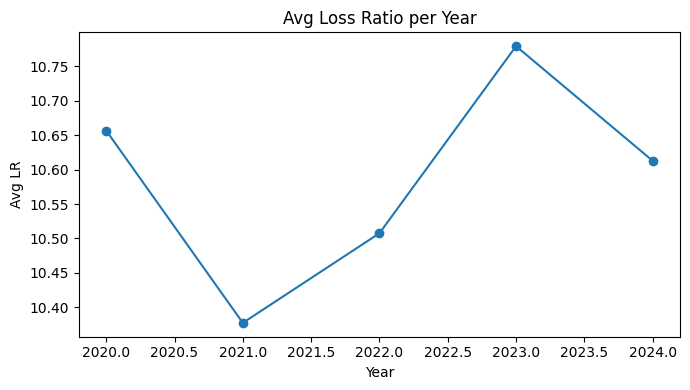

   region     avg_lr        total
6  FR-IDF  10.829885  54126901.42
0  DE-BAY  10.760701  56992297.61
5  BE-VLG  10.733113  94704062.91
3   NL-ZH  10.652908  68932317.40
4  BE-WAL  10.587200  59288292.87
2  DE-NRW  10.554338  69134865.02
1   NL-NH  10.539112  66303398.47
7  BE-BRU   9.918253  48486858.20


In [10]:
# loss ratio over time — split by year
DF['claim_date2'] = pd.to_datetime(DF['claim_date'], format='mixed', dayfirst=True)
DF['yr'] = DF['claim_date2'].dt.year
DF['LR2'] = DF['claim_amount'] / DF['premium']

YearSummary = []
for y in sorted(DF['yr'].dropna().unique()):
    sub = DF[DF['yr'] == y]
    YearSummary.append({'year': y, 'avg_lr': sub['LR2'].mean()})
YearSummary = pd.DataFrame(YearSummary)

plt.figure(figsize=(7, 4))
plt.plot(YearSummary['year'], YearSummary['avg_lr'], marker='o')
plt.title('Avg Loss Ratio per Year')
plt.xlabel('Year')
plt.ylabel('Avg LR')
plt.tight_layout()
plt.show()

# also show region table again for reference
print(Summary)